In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train['Age_imputed']=X_train['Age']
X_test['Age_imputed']=X_test['Age']

In [8]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [20]:
 X_train['Age_imputed'].isnull().sum()

np.int64(0)

In [22]:
missing = X_train['Age_imputed'].isnull().sum()

values = X_train['Age'].dropna().sample(
    n=missing,
    random_state=42
).values

X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = values


missing= X_test['Age_imputed'].isnull().sum()

values=X_test['Age'].dropna().sample(
      n=missing,
    random_state=42
).values

X_test.loc[X_test['Age_imputed'].isnull(),'Age_imputed']=values

In [23]:
X_train['Age_imputed'].isnull().sum()

np.int64(0)

In [24]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([30.  , 20.  , 39.  , 28.  , 46.  , 28.  , 59.  , 34.  , 28.  ,
       24.  , 42.  , 18.  , 24.  , 30.  , 19.  ,  7.  ,  4.  , 36.  ,
       17.  , 42.  , 47.  , 23.  , 32.  , 29.  , 24.  , 22.  , 29.  ,
       23.5 , 19.  , 60.  , 33.  , 19.  , 21.  , 25.  ,  0.75, 24.  ,
        9.  , 60.  , 22.  , 28.  , 46.  , 23.  , 24.  , 28.  , 58.  ,
       33.  , 38.  , 41.  , 16.  , 35.  , 22.  , 30.5 , 35.  , 24.  ,
       30.  , 14.  , 24.  , 34.  , 50.  , 28.  , 42.  , 26.  , 25.  ,
       33.  , 22.  , 63.  ,  6.  , 50.  , 49.  , 16.  , 15.  , 70.5 ,
       19.  , 35.  , 28.  , 29.  , 40.  , 40.5 , 25.  , 29.  , 30.  ,
       51.  , 22.  , 32.  ,  0.83, 58.  , 49.  , 40.5 , 34.  , 27.  ,
        5.  , 33.  , 32.  , 34.  , 61.  , 14.  , 24.  , 35.  , 22.  ,
       30.  , 54.  ,  1.  , 52.  , 37.  , 24.  , 28.  , 29.  , 43.  ,
       56.  , 39.  , 22.  , 23.  ,  2.  , 19.  , 18.  , 41.  , 15.  ,
       34.  , 36.  , 34.  , 26.  , 16.  , 32.5 , 36.  , 13.  , 56.  ,
       40.  , 27.  ,

In [25]:
X_train['Age'].isnull().sum()

np.int64(148)

In [26]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,40.0
493,71.0,49.5042,71.0
527,NaN,221.7792,19.0


C:\Users\Francis D'Souza\AppData\Local\Temp\ipykernel_15984\3564269548.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='original',hist=False)
C:\Users\Francis D'Souza\AppData\Local\Temp\ipykernel_15984\3564269548.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  s

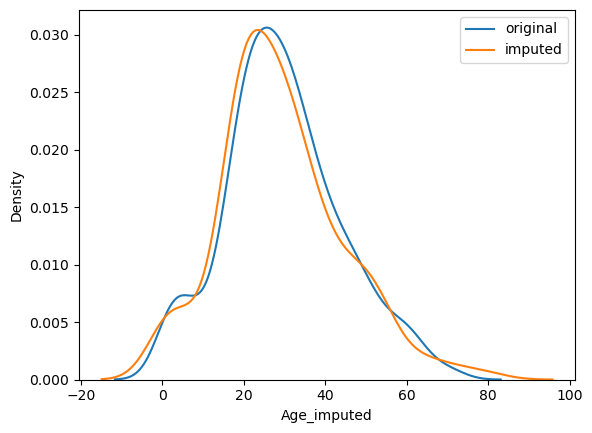

In [35]:
sns.distplot(X_train['Age'],label='original',hist=False)
sns.distplot(X_test['Age_imputed'],label='imputed',hist=False)

plt.legend()
plt.show()

In [38]:
print('origanl value variance',X_train['Age'].var())
print('imputed value variance',X_train['Age_imputed'].var())

origanl value variance 204.3495133904614
imputed value variance 203.41025663154437


In [45]:
X_train[['Age','Fare','Age_imputed']].cov()

,Age,Fare,Age_imputed
Age,204.349513,71.512440,204.349513
Fare,71.512440,2368.246832,56.504835
Age_imputed,204.349513,56.504835,203.410257


<Axes: >

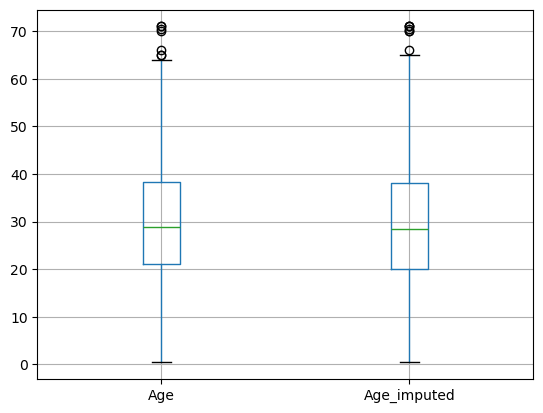

In [48]:
X_train[['Age','Age_imputed']].boxplot()

In [63]:
data=pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [64]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [66]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [67]:
X=data
y=data['SalePrice']

In [68]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [69]:
X_train['GarageQual_imputed']=X_train['GarageQual']
X_test['GarageQual_imputed']=X_test['GarageQual']

X_train['FireplaceQu_imputed']=X_train['FireplaceQu']
X_test['FireplaceQu_imputed']=X_test['FireplaceQu']

In [71]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
93,Gd,TA,133900,TA,Gd
150,NaN,TA,122000,TA,NaN
1239,Gd,TA,265900,TA,Gd
454,NaN,TA,188000,TA,NaN
1314,TA,TA,119000,TA,TA


In [76]:
missing = X_train['GarageQual_imputed'].isnull().sum()

values = X_train['GarageQual'].dropna().sample(
    n=missing,
    random_state=42
).values

X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = values


missing= X_test['GarageQual_imputed'].isnull().sum()

values=X_test['GarageQual'].dropna().sample(
      n=missing,
    random_state=42
).values

X_test.loc[X_test['GarageQual_imputed'].isnull(),'GarageQual_imputed']=values

In [77]:
missing = X_train['FireplaceQu_imputed'].isnull().sum()

values = X_train['FireplaceQu'].dropna().sample(
    n=missing,
    random_state=42
).values

X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = values


missing= X_test['FireplaceQu_imputed'].isnull().sum()

values=X_test['FireplaceQu'].dropna().sample(
      n=missing,
    random_state=42
).values

X_test.loc[X_test['FireplaceQu_imputed'].isnull(),'FireplaceQu_imputed']=values

In [83]:
temp=pd.concat([
        X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()),
        X_train['GarageQual_imputed'].value_counts()/len(X_train)
],axis=1)

temp.columns=['original','imputed']
temp

,original,imputed
TA,0.951087,0.951199
Fa,0.032609,0.031678
Gd,0.011775,0.012842
Ex,0.002717,0.002568
Po,0.001812,0.001712


C:\Users\Francis D'Souza\AppData\Local\Temp\ipykernel_15984\3183757375.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu']==category]['SalePrice'],hist=False,label=category)
C:\Users\Francis D'Souza\AppData\Local\Temp\ipykernel_15984\3183757375.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom

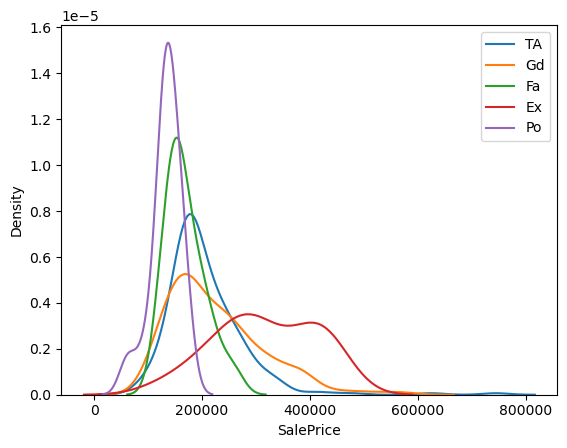

In [92]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu']==category]['SalePrice'],hist=False,label=category)
plt.legend()
plt.show()



C:\Users\Francis D'Souza\AppData\Local\Temp\ipykernel_15984\3839744479.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed']==category]['SalePrice'],hist=False,label=category)
C:\Users\Francis D'Souza\AppData\Local\Temp\ipykernel_15984\3839744479.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com

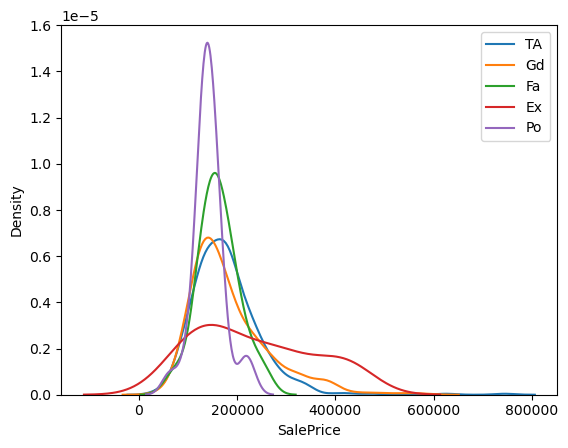

In [93]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed']==category]['SalePrice'],hist=False,label=category)
plt.legend()
plt.show()